# Multilayer Perceptron for IMDB Sentiment

This notebook trains a PyTorch MLP on the same IMDB reviews, preprocessing, tokenization, and TF-IDF representation used in Phase 1.

## Experiment design

Reviews that become identical after the model's preprocessing are deduplicated before a stratified 60/20/20 train/validation/test split. The vectorizer and normalization are fitted on training data only. The architecture, learning rate, epoch count, and decision threshold are fixed before training; validation metrics are monitored, while the test set is used once for the final report.

In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer
import torch
from torch import nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(8, os.cpu_count() or 1))
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gpu_name = "Not detected"
if shutil.which("nvidia-smi"):
    query = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=True,
    )
    gpu_name = query.stdout.strip()

current_path = Path.cwd().resolve()
repository_root = next(
    (
        path
        for path in (current_path, *current_path.parents)
        if (path / "phase-1-machine-learning-nlp").is_dir()
    ),
    None,
)
if repository_root is None:
    raise FileNotFoundError("Could not locate the repository root.")

phase_1 = repository_root / "phase-1-machine-learning-nlp"
part_02 = phase_1 / "02-preprocessing-tokenization"
part_06 = phase_1 / "06-vectorization"
sys.path.insert(0, str(part_02 / "src"))
sys.path.insert(0, str(part_06 / "src"))

from preprocessor import preprocess_text
from tokenizer import regex_tokenize
from vectorizer import CustomTfidfVectorizer

imdb_path = part_02 / "data" / "IMDB Dataset.csv"
if not imdb_path.exists():
    raise FileNotFoundError(
        "Download the IMDB 50K Reviews dataset and place 'IMDB Dataset.csv' in "
        f"{imdb_path.parent}. The CSV is intentionally ignored by Git."
    )

imdb = pd.read_csv(imdb_path)
required_columns = {"review", "sentiment"}
if not required_columns.issubset(imdb.columns):
    raise KeyError(f"The IMDB dataset must contain {sorted(required_columns)}.")
imdb = imdb.dropna(subset=["review", "sentiment"])
imdb["label"] = imdb["sentiment"].map({"negative": 0, "positive": 1})
if imdb["label"].isna().any():
    raise ValueError("Sentiment labels must be either 'negative' or 'positive'.")

def model_visible_text(review):
    cleaned = preprocess_text(
        str(review), remove_stopwords=False, apply_stemming=False
    )
    return " ".join(
        token
        for token in regex_tokenize(cleaned)
        if token.isalpha() and len(token) >= 2
    )


imdb["model_visible_text"] = imdb["review"].map(model_visible_text)
if imdb["model_visible_text"].eq("").any():
    raise ValueError("Preprocessing produced an empty review.")
if imdb.groupby("model_visible_text")["label"].nunique().gt(1).any():
    raise ValueError(
        "Reviews identical after preprocessing have conflicting labels."
    )
original_size = len(imdb)
imdb = imdb.drop_duplicates(subset="model_visible_text").reset_index(drop=True)

development, test = train_test_split(
    imdb,
    test_size=0.20,
    random_state=SEED,
    stratify=imdb["label"],
)
train, validation = train_test_split(
    development,
    test_size=0.25,
    random_state=SEED,
    stratify=development["label"],
)

split_frames = {"train": train, "validation": validation, "test": test}
for left, right in (("train", "validation"), ("train", "test"), ("validation", "test")):
    assert set(split_frames[left]["model_visible_text"]).isdisjoint(
        split_frames[right]["model_visible_text"]
    )

X_train, y_train = train["review"], train["label"]
X_validation, y_validation = validation["review"], validation["label"]
X_test, y_test = test["review"], test["label"]

split_summary = pd.DataFrame(
    {
        "reviews": [len(X_train), len(X_validation), len(X_test)],
        "positive proportion": [
            y_train.mean(),
            y_validation.mean(),
            y_test.mean(),
        ],
    },
    index=["train", "validation", "test"],
)

print(f"PyTorch: {torch.__version__}")
print(f"System GPU: {gpu_name}")
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
print(f"Selected device: {device}")
print(f"Reviews retained: {len(imdb):,} ({original_size - len(imdb):,} duplicates removed)")
print("Model-visible review overlap across splits: 0")
display(split_summary.style.format({"positive proportion": "{:.4f}"}))

PyTorch: 2.13.0+cpu
System GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
PyTorch CUDA available: False
Selected device: cpu
Reviews retained: 49,580 (420 duplicates removed)
Model-visible review overlap across splits: 0


,reviews,positive proportion
train,29748,0.5019
validation,9916,0.5019
test,9916,0.5019


## Normalization for ReLU

Activation functions behave best when their inputs have a controlled scale. Very large values can saturate bounded activations, while poorly scaled ReLU inputs can create unstable gradients or units that rarely activate.

This experiment L2-normalizes every sparse TF-IDF review so document length does not control the input magnitude. Each hidden linear layer is followed by batch normalization before ReLU, keeping its mini-batch inputs near zero mean and unit variance. Mean-centering the original TF-IDF matrix would destroy sparsity, so L2 input normalization plus hidden batch normalization is the practical choice here.

In [2]:
vectorizer = CustomTfidfVectorizer(
    preprocessor=preprocess_text,
    tokenizer=regex_tokenize,
    min_df=5,
    max_df=0.95,
    max_features=20_000,
)
input_normalizer = Normalizer(norm="l2", copy=False)

vectorization_start = time.perf_counter()
X_train_tfidf = input_normalizer.fit_transform(
    vectorizer.fit_transform(X_train)
).astype(np.float32)
X_validation_tfidf = input_normalizer.transform(
    vectorizer.transform(X_validation)
).astype(np.float32)
X_test_tfidf = input_normalizer.transform(
    vectorizer.transform(X_test)
).astype(np.float32)
vectorization_seconds = time.perf_counter() - vectorization_start

train_norms = np.sqrt(X_train_tfidf.multiply(X_train_tfidf).sum(axis=1)).A1
nonzero_norms = train_norms[train_norms > 0]
density = X_train_tfidf.nnz / np.prod(X_train_tfidf.shape)

print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")
print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Training matrix density: {density:.4%}")
print(f"Mean non-empty training-row L2 norm: {nonzero_norms.mean():.6f}")
print(f"Vectorization time: {vectorization_seconds:.2f} seconds")
assert np.allclose(nonzero_norms, 1.0, atol=1e-5)

Vocabulary size: 20,000
Training matrix shape: (29748, 20000)
Training matrix density: 0.6252%
Mean non-empty training-row L2 norm: 1.000000
Vectorization time: 17.16 seconds


## Why initialization must match the activation

Every layer repeatedly multiplies signals and gradients by its weights. If the initial variance is too small, both shrink toward zero; if it is too large, they grow and training becomes unstable. The correct scale depends on the activation because the activation changes the signal distribution. ReLU discards roughly half of a symmetric input, so Kaiming initialization compensates with variance `2 / fan_in`. The final linear logit layer uses Xavier initialization because it has no ReLU after it and should begin with moderate logits.

In [3]:
class SentimentMLP(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.hidden_1 = nn.Linear(input_features, 128)
        self.normalization_1 = nn.BatchNorm1d(128)
        self.hidden_2 = nn.Linear(128, 64)
        self.normalization_2 = nn.BatchNorm1d(64)
        self.output = nn.Linear(64, 1)
        nn.init.kaiming_normal_(self.hidden_1.weight, nonlinearity="relu")
        nn.init.zeros_(self.hidden_1.bias)
        nn.init.kaiming_normal_(self.hidden_2.weight, nonlinearity="relu")
        nn.init.zeros_(self.hidden_2.bias)
        nn.init.xavier_uniform_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, features):
        if features.is_sparse:
            hidden = torch.sparse.mm(features, self.hidden_1.weight.T)
            hidden = hidden + self.hidden_1.bias
        else:
            hidden = self.hidden_1(features)
        hidden = torch.relu(self.normalization_1(hidden))
        hidden = torch.relu(self.normalization_2(self.hidden_2(hidden)))
        return self.output(hidden).squeeze(1)


model = SentimentMLP(X_train_tfidf.shape[1]).to(device)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
expected_hidden_1_std = np.sqrt(2 / model.hidden_1.in_features)
observed_hidden_1_std = model.hidden_1.weight.detach().std().item()

print(model)
print(f"Trainable parameters: {parameter_count:,}")
print(f"First-layer expected Kaiming std: {expected_hidden_1_std:.6f}")
print(f"First-layer observed weight std: {observed_hidden_1_std:.6f}")
assert abs(observed_hidden_1_std / expected_hidden_1_std - 1.0) < 0.05

SentimentMLP(
  (hidden_1): Linear(in_features=20000, out_features=128, bias=True)
  (normalization_1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (hidden_2): Linear(in_features=128, out_features=64, bias=True)
  (normalization_2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (output): Linear(in_features=64, out_features=1, bias=True)
)
Trainable parameters: 2,568,833
First-layer expected Kaiming std: 0.010000
First-layer observed weight std: 0.009999


## Training

Sparse TF-IDF batches remain sparse through the first matrix multiplication. This avoids expanding the full 29,748 by 20,000 training matrix into dense memory. Binary cross-entropy with logits is used for the binary target, and Adam trains the fixed architecture for eight epochs.

Epoch  1/8 | train loss 0.3283 | validation loss 0.3436 | validation accuracy 0.8939 | validation F1 0.8938


Epoch  2/8 | train loss 0.0562 | validation loss 0.2743 | validation accuracy 0.8898 | validation F1 0.8910


Epoch  3/8 | train loss 0.0132 | validation loss 0.3063 | validation accuracy 0.8871 | validation F1 0.8888


Epoch  4/8 | train loss 0.0049 | validation loss 0.3273 | validation accuracy 0.8843 | validation F1 0.8842


Epoch  5/8 | train loss 0.0027 | validation loss 0.3428 | validation accuracy 0.8840 | validation F1 0.8846


Epoch  6/8 | train loss 0.0017 | validation loss 0.3584 | validation accuracy 0.8837 | validation F1 0.8832


Epoch  7/8 | train loss 0.0012 | validation loss 0.3685 | validation accuracy 0.8825 | validation F1 0.8836


Epoch  8/8 | train loss 0.0009 | validation loss 0.3797 | validation accuracy 0.8841 | validation F1 0.8840


,train loss,validation loss,validation accuracy,validation F1
epoch,,,,
1,0.3283,0.3436,0.8939,0.8938
2,0.0562,0.2743,0.8898,0.8910
3,0.0132,0.3063,0.8871,0.8888
4,0.0049,0.3273,0.8843,0.8842
5,0.0027,0.3428,0.8840,0.8846
6,0.0017,0.3584,0.8837,0.8832
7,0.0012,0.3685,0.8825,0.8836
8,0.0009,0.3797,0.8841,0.8840


Training and validation time: 32.70 seconds


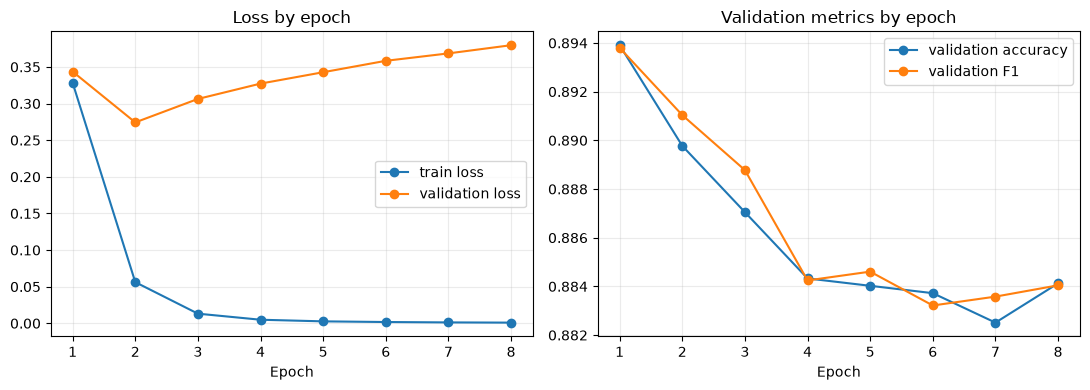

In [4]:
def to_sparse_batch(matrix, indices):
    batch = matrix[indices].tocoo()
    coordinates = np.vstack((batch.row, batch.col)).astype(np.int64)
    return torch.sparse_coo_tensor(
        torch.from_numpy(coordinates),
        torch.from_numpy(batch.data),
        size=batch.shape,
        device=device,
        check_invariants=False,
    ).coalesce()


def evaluate_model(model, matrix, labels, batch_size):
    model.eval()
    total_loss = 0.0
    probabilities = []
    with torch.no_grad():
        for start in range(0, len(labels), batch_size):
            indices = np.arange(start, min(start + batch_size, len(labels)))
            features = to_sparse_batch(matrix, indices)
            targets = torch.from_numpy(labels[indices]).to(device)
            logits = model(features)
            loss = loss_function(logits, targets)
            total_loss += loss.item() * len(indices)
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
    return total_loss / len(labels), np.concatenate(probabilities)


batch_size = 512
epochs = 8
learning_rate = 1e-3
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
y_train_array = y_train.to_numpy(dtype=np.float32)
y_validation_array = y_validation.to_numpy(dtype=np.float32)
history = []
training_start = time.perf_counter()

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0
    shuffled_indices = np.random.default_rng(SEED + epoch).permutation(
        len(y_train_array)
    )
    for start in range(0, len(y_train_array), batch_size):
        indices = shuffled_indices[start:start + batch_size]
        features = to_sparse_batch(X_train_tfidf, indices)
        targets = torch.from_numpy(y_train_array[indices]).to(device)
        optimizer.zero_grad()
        logits = model(features)
        loss = loss_function(logits, targets)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(indices)

    train_loss = epoch_loss / len(y_train_array)
    validation_loss, validation_probabilities = evaluate_model(
        model,
        X_validation_tfidf,
        y_validation_array,
        batch_size,
    )
    validation_predictions = (validation_probabilities >= 0.5).astype(int)
    validation_accuracy = accuracy_score(
        y_validation_array, validation_predictions
    )
    validation_f1 = f1_score(y_validation_array, validation_predictions)
    history.append(
        {
            "epoch": epoch,
            "train loss": train_loss,
            "validation loss": validation_loss,
            "validation accuracy": validation_accuracy,
            "validation F1": validation_f1,
        }
    )
    print(
        f"Epoch {epoch:>2}/{epochs} | train loss {train_loss:.4f} | "
        f"validation loss {validation_loss:.4f} | "
        f"validation accuracy {validation_accuracy:.4f} | "
        f"validation F1 {validation_f1:.4f}"
    )

training_seconds = time.perf_counter() - training_start
history_frame = pd.DataFrame(history).set_index("epoch")
display(history_frame.style.format("{:.4f}"))
print(f"Training and validation time: {training_seconds:.2f} seconds")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
history_frame[["train loss", "validation loss"]].plot(
    ax=axes[0], marker="o"
)
history_frame[["validation accuracy", "validation F1"]].plot(
    ax=axes[1], marker="o"
)
axes[0].set_title("Loss by epoch")
axes[1].set_title("Validation metrics by epoch")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

## Held-out test evaluation

The final epoch is evaluated once on the untouched test split. Accuracy and F1 summarize overall classification, precision and recall expose error balance, and ROC AUC evaluates probability ranking independently of the 0.5 threshold.

,test score
loss,0.3829
accuracy,0.8791
precision,0.8854
recall,0.8720
F1,0.8786
ROC AUC,0.9508


              precision    recall  f1-score   support

    negative     0.8730    0.8862    0.8795      4939
    positive     0.8854    0.8720    0.8786      4977

    accuracy                         0.8791      9916
   macro avg     0.8792    0.8791    0.8791      9916
weighted avg     0.8792    0.8791    0.8791      9916



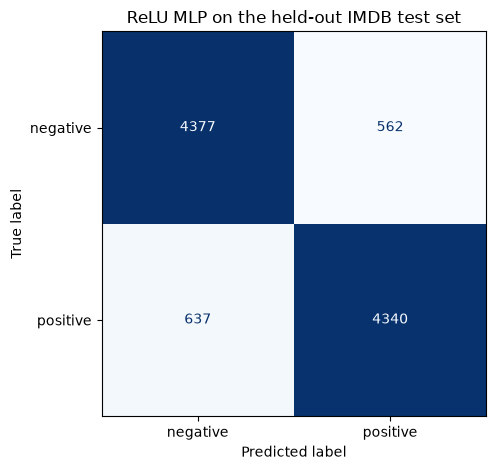

In [5]:
y_test_array = y_test.to_numpy(dtype=np.float32)
test_loss, test_probabilities = evaluate_model(
    model, X_test_tfidf, y_test_array, batch_size
)
test_predictions = (test_probabilities >= 0.5).astype(int)
test_metrics = pd.Series(
    {
        "loss": test_loss,
        "accuracy": accuracy_score(y_test_array, test_predictions),
        "precision": precision_score(y_test_array, test_predictions),
        "recall": recall_score(y_test_array, test_predictions),
        "F1": f1_score(y_test_array, test_predictions),
        "ROC AUC": roc_auc_score(y_test_array, test_probabilities),
    },
    name="test score",
).to_frame()

display(test_metrics.style.format("{:.4f}"))
print(classification_report(
    y_test_array,
    test_predictions,
    target_names=["negative", "positive"],
    digits=4,
))

ConfusionMatrixDisplay.from_predictions(
    y_test_array,
    test_predictions,
    display_labels=["negative", "positive"],
    cmap="Blues",
    colorbar=False,
)
plt.title("ReLU MLP on the held-out IMDB test set")
plt.tight_layout()
plt.show()

assert 0.0 <= test_metrics.loc["accuracy", "test score"] <= 1.0
assert len(test_predictions) == len(y_test_array)

## Observations

The fixed ReLU MLP reached test accuracy `0.8791`, F1 `0.8786`, and ROC AUC `0.9508`. Validation accuracy was highest after epoch 1 at `0.8939`, while validation loss was lowest after epoch 2 at `0.2743`; it then rose to `0.3797` as training loss fell to `0.0009`. This gap is clear evidence of overfitting, so later regularization and model-selection work can use this unregularized, fixed-eight-epoch model as the comparison baseline.